Prediction for 6: [7.1030303]
Coefficient : 1.0060606060606057
Intercept : 1.0666666666666682
MSE : 0.48969696969696963
R2 Score : 0.9446044151926505


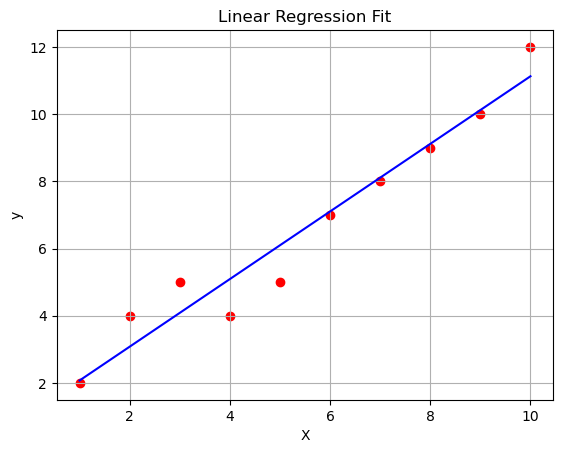

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2,4,5,4,5,7,8,9,10,12])

#training and predictions
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# model = LinearRegression()
# model.fit(X_train,y_train)
# y_pred = model.predict(X_test)


model = LinearRegression()
model.fit(X, y)
pred = model.predict(X)

print("Prediction for 6:", model.predict([[6]]))

print(f"Coefficient : {model.coef_[0]}")
print(f"Intercept : {model.intercept_}")
print(f"MSE : {mean_squared_error(y, pred)}")
print(f"R2 Score : {r2_score(y, pred)}")


plt.scatter(X, y, color='red')
plt.plot(X, model.predict(X), color='blue')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.grid(True)
plt.show()

# Diabetes dataset

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error

In [3]:
# !pip install matplotlib
# !pip install numpy
# !pip install scikit-learn

In [4]:
diabetes = datasets.load_diabetes()

In [5]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [6]:
diabetes.DESCR

'.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total cholesterol / HDL\n    - s5      ltg, possibly log of serum triglycerides level\n    - s6      glu, blood sugar level\n\nNote: Each of thes

In [7]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

Mean squared error: 3035.0601152912695
Weight: [941.43097333]
Intercept: 153.39713623331644


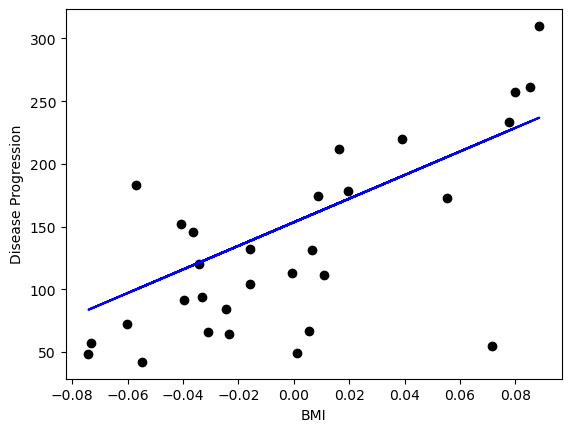

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error

diabetes = datasets.load_diabetes()

# Use only ONE feature (BMI)
diabetes_X = diabetes.data[:, np.newaxis, 2]
# The above code means:
#     : → take all rows.
#     2 → take the 3rd feature column (BMI in this dataset).
#     np.newaxis → add an extra dimension so result stays 2D.
#     Result shape becomes (442, 1).

diabetes_X_train = diabetes_X[:-30]
diabetes_X_test = diabetes_X[-30:]

# What it means:

# : means from the beginning.
# -30 means stop before the 30th item from the end.
# So training data gets the first part, and the last 30 are left out for testing.
# If diabetes_X has 442 rows, then:

# diabetes_X_train has 412 rows
# the remaining 30 rows are usually used by diabetes_X_test = diabetes_X[-30:]
# So this line is creating the training feature set.



# target is the class labels 

diabetes_y_train = diabetes.target[:-30]
diabetes_y_test = diabetes.target[-30:]

model = linear_model.LinearRegression()
model.fit(diabetes_X_train, diabetes_y_train)

diabetes_y_predicted = model.predict(diabetes_X_test)

print("Mean squared error:", mean_squared_error(diabetes_y_test, diabetes_y_predicted))
print("Weight:", model.coef_)
print("Intercept:", model.intercept_)

plt.scatter(diabetes_X_test, diabetes_y_test, color="black")
plt.plot(diabetes_X_test, diabetes_y_predicted, color="blue")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.show()


# Mean squared error is:  3035.0601152912695
# Weights:  [941.43097333]
# Intercept:  153.39713623331698


# linear regression from scratch

In [10]:
import numpy as np

X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Parameters
w = 0.0
b = 0.0
lr = 0.01
epochs = 1000
n = len(X)

# Training loop
for _ in range(epochs):
    y_pred = w * X + b
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    w -= lr * dw
    b -= lr * db

print("Weight:", w)
print("Bias:", b)


# plt.scatter(X, y, color='red')
# plt.plot(X, y_pred, color='blue')
# plt.xlabel("X")
# plt.ylabel("y")
# plt.title("Linear Regression Fit")
# plt.grid(True)
# plt.show()


Weight: 1.9951803506719779
Bias: 0.017400463340610635


## Linear Regression on the Iris Dataset: Predicting Petal Length from Sepal Length

Prediction for Sepal Length = 6: 4.049154499926592


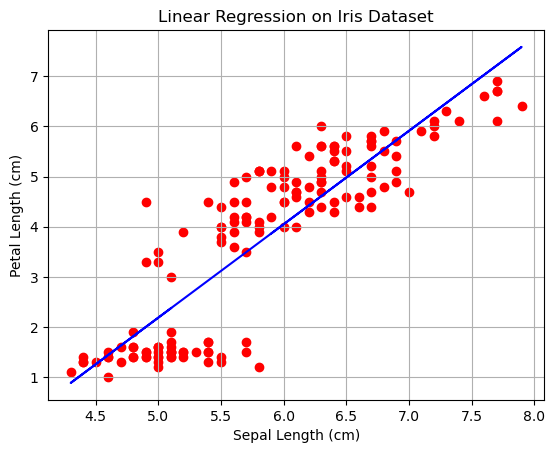

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()

# Select features
X = iris.data[:, 0].reshape(-1, 1)   # Sepal length
# X = iris.data[:, 0]
# Reshape your data either using array.reshape(-1, 1) if your data 
# has a single feature or array.reshape(1, -1) if it contains a 
# single sample.
y = iris.data[:, 2]                 # Petal length

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Prediction example
print("Prediction for Sepal Length = 6:",
      model.predict([[6]])[0])

# Visualization
plt.scatter(X, y, color='red')
plt.plot(X, model.predict(X), color='blue')
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Linear Regression on Iris Dataset")
plt.grid(True)
plt.show()


for the line
y = iris.data[:,2].reshape(-1,1)
does this also work:y = iris.data[:,2]

if yes or no then why did we had to choose X = iris.data[:,0].reshape(-1,1)
ie why did we choose reshape here in x and not in y

Short answer:
1. Yes, this works for y:
   y = iris.data[:, 2]
2. For X, this does not work:
   X = iris.data[:, 0]
   unless you reshape it.

Why:
1. Scikit-learn expects input features X as 2D with shape (n_samples, n_features).
2. iris.data[:, 0] gives shape (150,) which is 1D, so model.fit will complain.
3. iris.data[:, 0].reshape(-1, 1) gives shape (150, 1), which is correct for one feature.

For y (target):
1. Single-target regression usually uses 1D y with shape (n_samples,).
2. So y = iris.data[:, 2] is the standard form.
3. y = iris.data[:, 2].reshape(-1, 1) can still work, but it is treated as a 2D target column (multi-output style with one output), which is usually unnecessary here.

So the common clean version is:
X = iris.data[:, 0].reshape(-1, 1)
y = iris.data[:, 2]

That is why you reshape X but usually not y.

In [12]:
iris.data[:,2]

array([1.4, 1.4, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5, 1.5, 1.6, 1.4,
       1.1, 1.2, 1.5, 1.3, 1.4, 1.7, 1.5, 1.7, 1.5, 1. , 1.7, 1.9, 1.6,
       1.6, 1.5, 1.4, 1.6, 1.6, 1.5, 1.5, 1.4, 1.5, 1.2, 1.3, 1.4, 1.3,
       1.5, 1.3, 1.3, 1.3, 1.6, 1.9, 1.4, 1.6, 1.4, 1.5, 1.4, 4.7, 4.5,
       4.9, 4. , 4.6, 4.5, 4.7, 3.3, 4.6, 3.9, 3.5, 4.2, 4. , 4.7, 3.6,
       4.4, 4.5, 4.1, 4.5, 3.9, 4.8, 4. , 4.9, 4.7, 4.3, 4.4, 4.8, 5. ,
       4.5, 3.5, 3.8, 3.7, 3.9, 5.1, 4.5, 4.5, 4.7, 4.4, 4.1, 4. , 4.4,
       4.6, 4. , 3.3, 4.2, 4.2, 4.2, 4.3, 3. , 4.1, 6. , 5.1, 5.9, 5.6,
       5.8, 6.6, 4.5, 6.3, 5.8, 6.1, 5.1, 5.3, 5.5, 5. , 5.1, 5.3, 5.5,
       6.7, 6.9, 5. , 5.7, 4.9, 6.7, 4.9, 5.7, 6. , 4.8, 4.9, 5.6, 5.8,
       6.1, 6.4, 5.6, 5.1, 5.6, 6.1, 5.6, 5.5, 4.8, 5.4, 5.6, 5.1, 5.1,
       5.9, 5.7, 5.2, 5. , 5.2, 5.4, 5.1])

In [13]:
iris.data[:,0].reshape(-1,1)

array([[5.1],
       [4.9],
       [4.7],
       [4.6],
       [5. ],
       [5.4],
       [4.6],
       [5. ],
       [4.4],
       [4.9],
       [5.4],
       [4.8],
       [4.8],
       [4.3],
       [5.8],
       [5.7],
       [5.4],
       [5.1],
       [5.7],
       [5.1],
       [5.4],
       [5.1],
       [4.6],
       [5.1],
       [4.8],
       [5. ],
       [5. ],
       [5.2],
       [5.2],
       [4.7],
       [4.8],
       [5.4],
       [5.2],
       [5.5],
       [4.9],
       [5. ],
       [5.5],
       [4.9],
       [4.4],
       [5.1],
       [5. ],
       [4.5],
       [4.4],
       [5. ],
       [5.1],
       [4.8],
       [5.1],
       [4.6],
       [5.3],
       [5. ],
       [7. ],
       [6.4],
       [6.9],
       [5.5],
       [6.5],
       [5.7],
       [6.3],
       [4.9],
       [6.6],
       [5.2],
       [5. ],
       [5.9],
       [6. ],
       [6.1],
       [5.6],
       [6.7],
       [5.6],
       [5.8],
       [6.2],
       [5.6],
       [5.9],
      

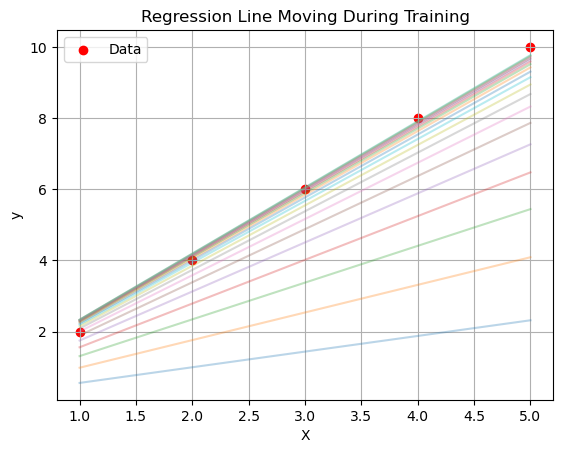

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Parameters
w = 0.0
b = 0.0
lr = 0.01
epochs = 20
n = len(X)

losses = []
lines = []

# Training loop
for _ in range(epochs):
    y_pred = w * X + b
    
    # Mean Squared Error
    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)
    
    # Gradients
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    # Update
    w -= lr * dw
    b -= lr * db
    
    # Store line
    lines.append((w, b))

plt.scatter(X, y, color='red', label='Data')

for i, (w_i, b_i) in enumerate(lines):
    plt.plot(X, w_i * X + b_i, alpha=0.3)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Line Moving During Training")
plt.legend()
plt.grid(True)
plt.show()



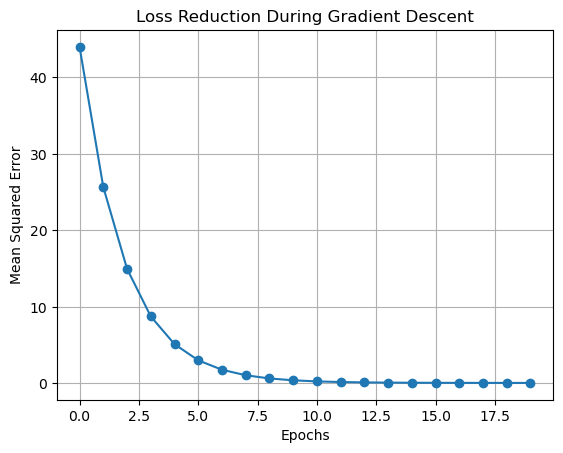

In [15]:
plt.plot(losses, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Loss Reduction During Gradient Descent")
plt.grid(True)
plt.show()


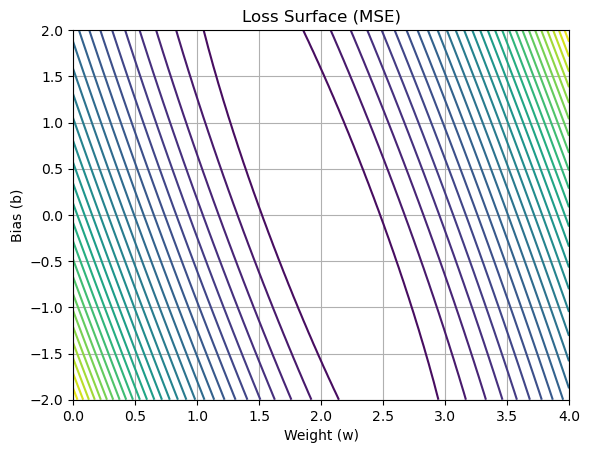

In [16]:
W = np.linspace(0, 4, 100)
B = np.linspace(-2, 2, 100)
W_grid, B_grid = np.meshgrid(W, B)

Z = np.zeros(W_grid.shape)

for i in range(len(W)):
    for j in range(len(B)):
        y_hat = W_grid[j,i] * X + B_grid[j,i]
        Z[j,i] = np.mean((y - y_hat) ** 2)

plt.contour(W_grid, B_grid, Z, levels=30)
plt.xlabel("Weight (w)")
plt.ylabel("Bias (b)")
plt.title("Loss Surface (MSE)")
plt.grid(True)
plt.show()
